# Project 2 - Part 1: Basic Modelling

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### **Deterministic model (ODEs)**

Deterministic model (ODEs):

\begin{align*}
\frac{dS}{dt} &= -\frac{\beta}{N}IS, \\
\frac{dI}{dt} &= \frac{\beta}{N}IS - \gamma I, \\
\frac{dR}{dt} &= \gamma I.
\end{align*}

Baisc reproduction number: 5.0


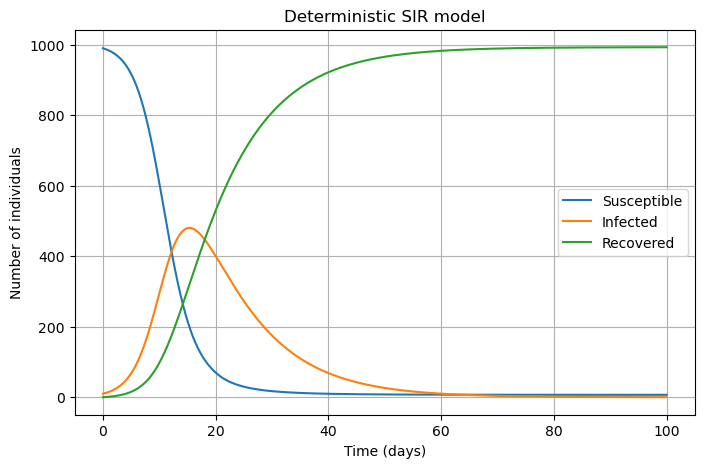

In [29]:
# Parameters
N = 1000 # Total population size
beta = 0.5
gamma = 0.1
I0 = 0.01*N # Initial number of infected
R0 = 0 # Initial number of recovered
S0 = N - I0 - R0 # Initial number of susceptible 

# Time interval
t_start = 0
t_end = 100
t_vals = np.linspace(t_start, t_end, 1000)

# SIR ODE system
def sir_ode(t, y, beta, gamma, N):
    S, I, R = y

    dSdt = - beta/N * I * S
    dIdt = beta/N * I * S - gamma * I
    dRdt = gamma * I

    return (dSdt, dIdt, dRdt)

# Solve ODE system using solve_ivp (used to "Solve an initial value problem for a system of ODEs")
sol = solve_ivp(fun=sir_ode, t_span=(t_start, t_end), y0=[S0, I0, R0], args=[beta, gamma, N], t_eval=t_vals)

# Extract solution
S, I, R = sol.y

# Basic reproduction number
R_0 = beta / gamma
print(f"Baisc reproduction number: {R_0}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sol.t, S, label="Susceptible")
plt.plot(sol.t, I, label="Infected")
plt.plot(sol.t, R, label="Recovered")
plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Deterministic SIR model")
plt.legend()
plt.grid()
plt.show()

### **Stochastic Continuous-Time Markov Chains**

Using slide 6-8 in the slide Markov chains.pdf for the exponentially distributed times until next event.

In [ ]:
#%% CTMC SIR simulation function

def simulate_sir_ctmc(N, beta, gamma, I0=1, R0=0, t_max=100, seed=None):
    
    # Set seed for reproducibility (if seed is not None)
    if seed is not None:
        np.random.seed(seed)

    # Initial condition
    S = N - I0 - R0
    I = I0
    R = R0
    t = 0

    # Initialize lists to save results
    times = [t]
    S_values = [S]
    I_values = [I]
    R_values = [R]

    # Run simulation until time limit or until there are no more infected 
    while I > 0 and t < t_max:

        # Compute event rates
        I_rate = beta * S * I / N # rate of getting infected 
        R_rate = gamma * I # rate of recovering
        total_rate = I_rate + R_rate # total rate of leaving the current state

        # If no people move between compartments, break
        if total_rate == 0:
            break

        # Time to next event
        dt = np.random.exponential(scale=1 / total_rate) # Exponentially distributed
        t += dt

        # Random uniform number in [0,1]
        U = np.random.rand()

        # Choose event type
        if U < I_rate / total_rate: # P(Event = infection) = I_rate / total_rate = rate of getting infected / total rate of leaving the current state
            # Infection: S -> I
            S -= 1
            I += 1
        else: # P(Event = recovered) = R_rate / total_rate = rate of recovering / total rate of leaving the current state
            # Recovery: I -> R
            I -= 1
            R += 1

        # Save results
        times.append(t)
        S_values.append(S)
        I_values.append(I)
        R_values.append(R)

    return np.array(times), np.array(S_values), np.array(I_values), np.array(R_values)

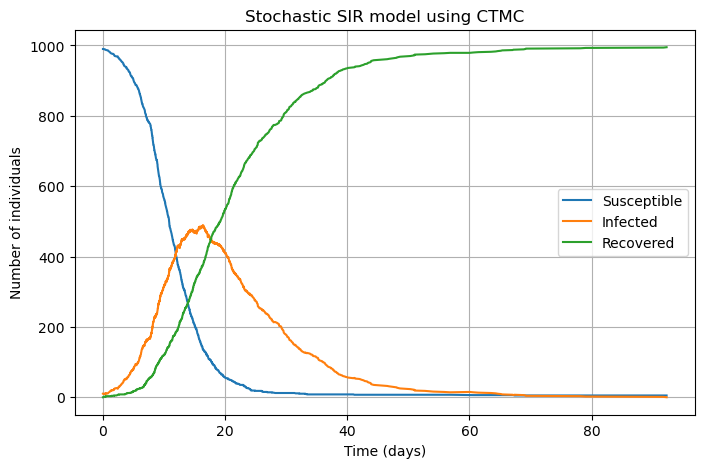

In [ ]:
#%% Run simulation
times, S, I, R = simulate_sir_ctmc(N=N, beta=beta, gamma=gamma, I0=I0, R0=R0, t_max=t_end, seed=42)

# OBS: SHOULD PROBABLY RUN SEVERAL TIMES AND TAKE THE MEAN

#%% Plot
plt.figure(figsize=(8, 5))
plt.plot(times, S, label="Susceptible")
plt.plot(times, I, label="Infected")
plt.plot(times, R, label="Recovered")
plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model using CTMC")
plt.legend()
plt.grid()
plt.show()